Model - Validation Accuracy - Epoch

Dense - 84.11 - 2

CNN - 89.35 - 3

In [ ]:
import keras
from keras.datasets import imdb
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Dense, Dropout, Embedding
from keras.layers import SpatialDropout1D, Conv1D, GlobalMaxPooling1D # new!
from keras.callbacks import ModelCheckpoint
import os
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# output directory name:
output_dir = 'model_output/conv'

# training:
epochs = 4
batch_size = 128

# vector-space embedding:
n_dim = 64
n_unique_words = 5000
max_review_length = 400
pad_type = trunc_type = 'pre'
drop_embed = 0.2 # new!

# convolutional layer architecture:
n_conv = 256 # filters, a.k.a. kernels
k_conv = 3 # kernel length

# dense layer architecture:
n_dense = 256
dropout = 0.2

In [ ]:
(x_train, y_train), (x_valid, y_valid) = imdb.load_data(num_words=n_unique_words) # removed n_words_to_skip

In [ ]:
x_train = pad_sequences(x_train, maxlen=max_review_length, padding=pad_type, truncating=trunc_type, value=0)
x_valid = pad_sequences(x_valid, maxlen=max_review_length, padding=pad_type, truncating=trunc_type, value=0)

In [ ]:
model = Sequential()
# 1st hidden layer: vector-space embedding
model.add(Embedding(input_dim=n_unique_words,output_dim=n_dim,input_shape=(max_review_length,)))
model.add(SpatialDropout1D(drop_embed)) # no Flatten(),Conv1D() layer takes multidimension

# 2nd hidden layer : convolutional layer
# We use relu activation within our one-dimensional convolutional layer. The layer has
# 256 unique filters, each of which is free to specialize in activating when it passes over
# a particular three-token sequence. The activation map for each of the 256 filters has a
# length of 398, corresponding to a 398x256 output shape
model.add(Conv1D(n_conv, k_conv, activation='relu'))
# model.add(Conv1D(n_conv, k_conv, activation='relu')) # can add more hidden layer

# Global max-pooling is common for dimensionality reduction within deep learning NLP models.
# We use it here to squash the activation map from 398 x 256 to 1 x 256. By applying it, only
# the magnitude of largest activation for a given convolutional filter is retained by the
# maximum-calculating operation, and we lose any temporal-position-specific information the
# filter may have output to its 398-element-long activation map
model.add(GlobalMaxPooling1D()) # not a hidden layer

# Dense layer
# Because the activations output from the global max-pooling layer are one-dimensional,
# they can be fed directly into the dense layer, which consists (again) of relu neurons and
# dropout is applied
model.add(Dense(n_dense, activation='relu'))
model.add(Dropout(dropout))

# Output layer
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

modelcheckpoint = ModelCheckpoint(filepath=output_dir+"/model_epoch_{epoch:02d}.keras")
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [ ]:
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, verbose=1, validation_data=(x_valid, y_valid), callbacks=[modelcheckpoint])

Epoch 1/4
196/196 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.7444 - loss: 0.4857 - val_accuracy: 0.8716 - val_loss: 0.3015
Epoch 2/4
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8972 - loss: 0.2480 - val_accuracy: 0.8799 - val_loss: 0.2837
Epoch 3/4
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9340 - loss: 0.1754 - val_accuracy: 0.8935 - val_loss: 0.2671
Epoch 4/4
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9614 - loss: 0.1136 - val_accuracy: 0.8862 - val_loss: 0.3094


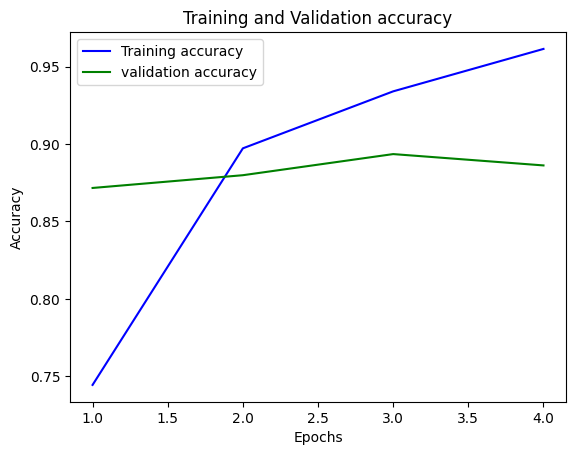

In [ ]:
loss_train = history.history['accuracy']
loss_val = history.history['val_accuracy']
epochs = range(1, 5) # if epoch 10, then give 11 instead of 4
plt.plot(epochs, loss_train, 'b', label='Training accuracy')
plt.plot(epochs, loss_val, 'g', label='validation accuracy')
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

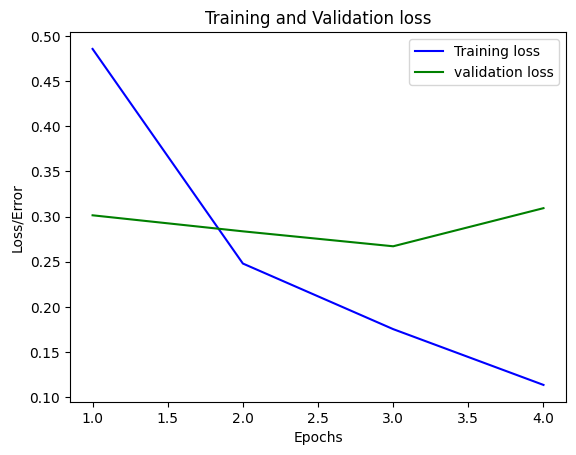

In [ ]:
loss_train = history.history['loss']
loss_val = history.history['val_loss']
epochs = range(1, 5) # if epoch 10, then give 11 instead of 4
plt.plot(epochs, loss_train, 'b', label='Training loss')
plt.plot(epochs, loss_val, 'g', label='validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss/Error')
plt.legend()
plt.show()

In [ ]:
model.load_weights(output_dir+"/model_epoch_03.keras")

y_hat = model.predict(x_valid)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


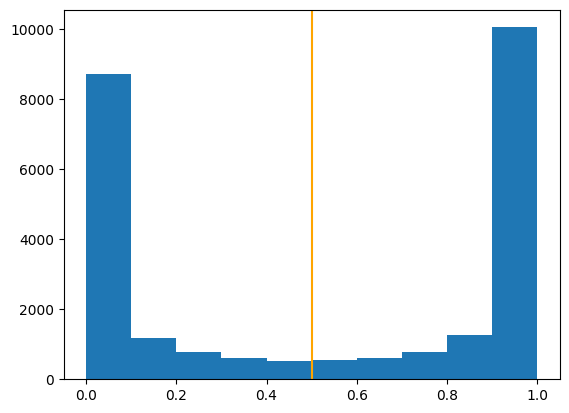

In [ ]:
plt.hist(y_hat)
_ = plt.axvline(x=0.5, color='orange')

In [ ]:
"{:0.2f}".format(roc_auc_score(y_valid, y_hat)*100.0)

'96.03'

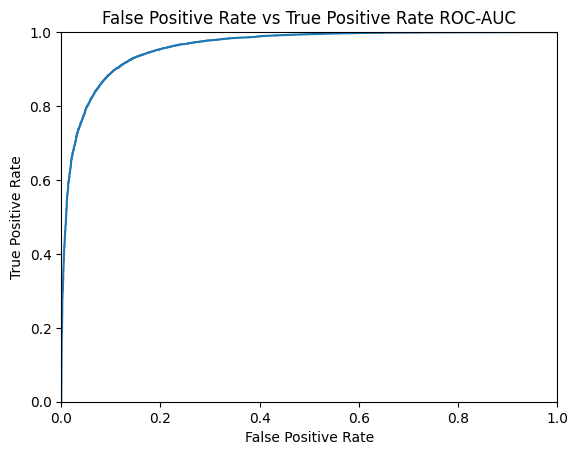

In [ ]:
fpr , tpr , thresholds = roc_curve (y_valid , y_hat)
plt.plot(fpr,tpr)
plt.axis([0,1,0,1])
plt.title('False Positive Rate vs True Positive Rate ROC-AUC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()